In [1]:
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

In [2]:
df_data = pd.read_excel('Новый диплом датасет.xlsx', sheet_name='Данные')
df_cl = pd.read_excel('Новый диплом датасет.xlsx', sheet_name='Clients')
df_reg = pd.read_excel('Новый диплом датасет.xlsx', sheet_name='Region_dict')

In [3]:
df_data['dtime_pay'] = pd.to_datetime(df_data['dtime_pay'], dayfirst=True)
df_cl['dtime_ad'] = pd.to_datetime(df_cl['dtime_ad'], dayfirst=True)
df_data['id_client'] = df_data['id_client'].fillna(0).astype(int)

In [4]:
##Функция очистки данных(В столбцах с числами пропуски заменяет на 0 и приводит к Int, пропуски дат ставит минимальную возможную дату.
def clear_df(df):
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(0).astype(int)
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].fillna(pd.Timestamp(0))
        else:
            df[col] = df[col].fillna('0')
    return df






In [5]:
##Из очищенного датасета убираем не индифицированных пользователей.
df_data = clear_df(df_data)
df_data_new = df_data[df_data['id_client'] != 0]
df_data_new

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569,5373,2022-10-28 04:05:15.221
1,100242,191056,4151,2022-08-01 02:42:54.992
2,100249,200049,5688,2022-08-24 12:45:12.744
3,100258,206161,4330,2022-12-09 15:13:26.437
4,100267,190945,5488,2022-08-03 02:07:31.468
...,...,...,...,...
37983,297572,195257,2191,2022-08-21 18:31:51.585
37985,297593,179230,5755,2022-09-05 03:29:07.726
37986,297595,192530,4448,2022-09-27 23:50:05.734
37987,297601,183888,1746,2022-10-13 14:23:03.073


In [6]:
df_cl = clear_df(df_cl)
df_cl

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,1970-01-01 00:00:00.000,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015
...,...,...,...,...
55600,193038,2022-07-09 00:31:25.196,0,1015
55601,244069,2022-08-08 00:12:31.319,1,991
55602,189084,2022-06-29 04:34:42.610,1,439
55603,182758,2022-06-13 11:28:37.856,1,573


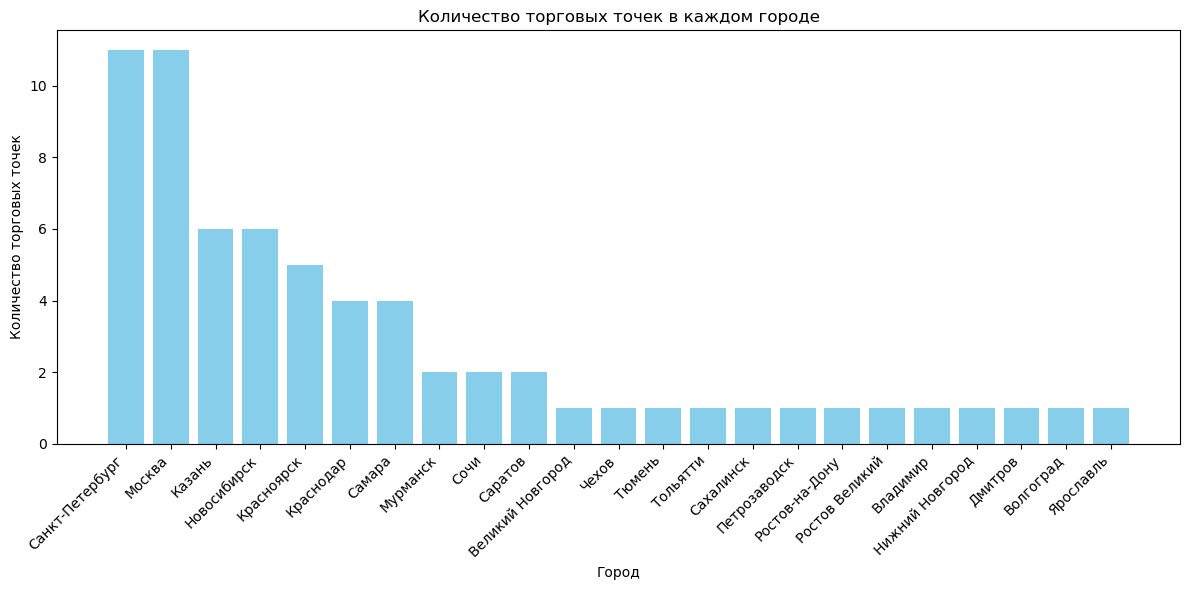

In [7]:
city_counts = df_reg.groupby('city')['id_trading_point'].nunique().reset_index()
city_counts_sorted = city_counts.sort_values('id_trading_point', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(city_counts_sorted['city'], city_counts_sorted['id_trading_point'], color='skyblue')
plt.xlabel('Город')
plt.ylabel('Количество торговых точек')
plt.title('Количество торговых точек в каждом городе')
plt.xticks(rotation=45, ha='right')  
plt.tight_layout()
plt.show()

In [8]:
##Список покупок с ошибками( нет данных о пользователях)
df_data_noid = df_data[df_data['id_client'] == 0]
df_data_noid

,id_order,id_client,amt_payment,dtime_pay
61,100524,0,0,1970-01-01
87,100645,0,0,1970-01-01
88,100651,0,0,1970-01-01
287,101672,0,0,1970-01-01
308,101773,0,0,1970-01-01
...,...,...,...,...
37782,296379,0,0,1970-01-01
37891,297076,0,0,1970-01-01
37927,297263,0,0,1970-01-01
37970,297490,0,0,1970-01-01


In [9]:
##Соединение таблиц в финальный дата сет.
df_new = pd.merge(df_data_new, df_cl, on='id_client', how='outer')
df_fin = pd.merge(df_new, df_reg, on='id_trading_point', how='outer')
df_fin



,id_order,id_client,amt_payment,dtime_pay,dtime_ad,nflag_test,id_trading_point,city
0,229642.0,179078,0.0,1970-01-01,2022-06-04 10:24:36.791,1,1,Петрозаводск
1,171426.0,180567,0.0,1970-01-01,2022-06-08 02:30:22.264,1,1,Петрозаводск
2,264840.0,180624,0.0,1970-01-01,2022-06-08 06:00:02.382,1,1,Петрозаводск
3,250017.0,181891,0.0,1970-01-01,2022-06-11 08:07:21.568,1,1,Петрозаводск
4,292267.0,181980,0.0,1970-01-01,2022-06-11 12:49:55.528,1,1,Петрозаводск
...,...,...,...,...,...,...,...,...
63289,NaN,328288,NaN,NaT,2022-06-17 12:37:53.456,1,9931,Москва
63290,NaN,328329,NaN,NaT,2022-07-11 00:50:46.371,1,9931,Москва
63291,NaN,329081,NaN,NaT,2022-08-05 19:56:26.232,1,9931,Москва
63292,NaN,329458,NaN,NaT,2022-06-15 18:05:27.213,1,9931,Москва


In [10]:
df_fin_clear = clear_df(df_fin)
df_fin_clear

,id_order,id_client,amt_payment,dtime_pay,dtime_ad,nflag_test,id_trading_point,city
0,229642,179078,0,1970-01-01,2022-06-04 10:24:36.791,1,1,Петрозаводск
1,171426,180567,0,1970-01-01,2022-06-08 02:30:22.264,1,1,Петрозаводск
2,264840,180624,0,1970-01-01,2022-06-08 06:00:02.382,1,1,Петрозаводск
3,250017,181891,0,1970-01-01,2022-06-11 08:07:21.568,1,1,Петрозаводск
4,292267,181980,0,1970-01-01,2022-06-11 12:49:55.528,1,1,Петрозаводск
...,...,...,...,...,...,...,...,...
63289,0,328288,0,1970-01-01,2022-06-17 12:37:53.456,1,9931,Москва
63290,0,328329,0,1970-01-01,2022-07-11 00:50:46.371,1,9931,Москва
63291,0,329081,0,1970-01-01,2022-08-05 19:56:26.232,1,9931,Москва
63292,0,329458,0,1970-01-01,2022-06-15 18:05:27.213,1,9931,Москва


In [11]:
df_sumpay =  df_fin_clear.groupby('id_client')['amt_payment'].sum().reset_index()
df_sumpay.rename(columns={'amt_payment': 'total_payments'}, inplace=True)
df_sumpay

,id_client,total_payments
0,178561,3052
1,178562,2439
2,178563,768
3,178564,0
4,178565,958
...,...,...
55600,331949,0
55601,331950,0
55602,331954,0
55603,331955,0


In [12]:
df_merg = pd.merge(df_cl, df_sumpay, on='id_client', how='left')
df_merg
df_fin_merg = pd.merge(df_merg, df_reg, on='id_trading_point', how='left')
df_fin_merg
df_fin_merg['flag_pay'] = df_fin_merg['total_payments'].apply(lambda x: 1 if x > 0 else 0)
df_fin_merg

,id_client,dtime_ad,nflag_test,id_trading_point,total_payments,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,1970-01-01 00:00:00.000,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
4,322530,2022-07-08 08:56:08.714,0,1015,0,Краснодар,0
...,...,...,...,...,...,...,...
55600,193038,2022-07-09 00:31:25.196,0,1015,5846,Краснодар,1
55601,244069,2022-08-08 00:12:31.319,1,991,0,Казань,0
55602,189084,2022-06-29 04:34:42.610,1,439,7146,Казань,1
55603,182758,2022-06-13 11:28:37.856,1,573,13720,Санкт-Петербург,1


In [13]:
def test_calc(r1, r2, alpha=0.05):
    # Выполняем t-тест для независимых выборок
    t_stat, p_value = ttest_ind(r1, r2, equal_var=False)  # Welch's t-test
    
    # Выводим результаты
    print(f"t-критерий: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Проверяем гипотезу
    if p_value < alpha:
        print(f"Различия между средними статистически значимы (p < {alpha})")
    else:
        print(f"Нет статистически значимых различий между средними (p >= {alpha})")


In [14]:
control = df_fin_merg[df_fin_merg['nflag_test'] == 0]['total_payments']
test = df_fin_merg[df_fin_merg['nflag_test'] == 1]['total_payments']

In [15]:
test_calc( control, test, alpha=0.05)


t-критерий: -6.5183
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)


In [16]:
def mann_whitney_func(r1, r2, alpha=0.05):
    # Выполняем тест Манна-Уитни
    stat, p_value = mannwhitneyu(r1, r2, alternative='two-sided')
    
    # Выводим результаты
    print(f"Критерий Манна-Уитни: {stat:.4f}")
    print(f"p-value: {p_value:.4f}")
    
    # Проверяем гипотезу
    if p_value < alpha:
        print(f"Различия между распределениями статистически значимы (p < {alpha})")
    else:
        print(f"Нет статистически значимых различий между распределениями (p >= {alpha})")

In [17]:
mann_whitney_func( control, test, alpha=0.05)

Критерий Манна-Уитни: 373181988.5000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)


In [20]:
trading_points_with_no_payments = []

# Получаем все уникальные торговые точки
unique_points = df_fin_merg['id_trading_point'].unique()

# Проходим по каждой торговой точке
for i in df_fin_merg['id_trading_point'].unique():
    
    sum_a = df_fin_merg[(df_fin_merg['id_trading_point']==i) & (df_fin_merg['nflag_test']==0)]['total_payments'].sum()
    sum_b = df_fin_merg[(df_fin_merg['id_trading_point']==i) & (df_fin_merg['nflag_test']==1)]['total_payments'].sum()
    if (sum_a == 0) | (sum_b == 0):
        trading_points_with_no_payments.append(i)
        
print(trading_points_with_no_payments)

[1015, 866, 1099, 739, 46, 228, 26, 603, 810, 800, 7, 4, 1]


In [21]:
# Создаем пустой список
trading_points_with_empty_group = []

# Получаем все уникальные торговые точки
unique_points = df_fin_merg['id_trading_point'].unique()

# Проходим по каждой торговой точке
for point in unique_points:
    # Фильтруем данные по текущей торговой точке
    df_point = df_fin_merg[df_fin_merg['id_trading_point'] == point]
    
    # Проверяем наличие групп (0 и 1)
    for group_flag in [0, 1]:
        # Проверяем, есть ли клиенты в этой группе
        group_clients = df_point[df_point['nflag_test'] == group_flag]
        if group_clients.empty:
            # Если группа пустая, добавляем торговую точку и прерываем цикл
            trading_points_with_empty_group.append(point)
            break  # переходим к следующей торговой точке

# Выводим результат
print(trading_points_with_empty_group)

[1015, 866, 1099, 739, 228, 603, 810, 800]


In [32]:
excluded_points = set(trading_points_with_no_payments) | set(trading_points_with_empty_group)
df_fin_filt = df_fin_merg[~df_fin_merg['id_trading_point'].isin(excluded_points)]
df_fin_filt

,id_client,dtime_ad,nflag_test,id_trading_point,total_payments,city,flag_pay
0,180844,2022-06-08 18:38:41.414,0,212,5349,Красноярск,1
1,193942,1970-01-01 00:00:00.000,0,13,4144,Нижний Новгород,1
2,226069,2022-07-11 16:28:38.511,1,54,0,Мурманск,0
3,183981,2022-06-16 12:23:59.289,1,991,6322,Казань,1
5,254313,2022-06-19 22:18:01.770,1,453,0,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55599,188702,2022-06-28 06:16:25.664,0,453,1323,Санкт-Петербург,1
55601,244069,2022-08-08 00:12:31.319,1,991,0,Казань,0
55602,189084,2022-06-29 04:34:42.610,1,439,7146,Казань,1
55603,182758,2022-06-13 11:28:37.856,1,573,13720,Санкт-Петербург,1


In [33]:
control_new = df_fin_filt[df_fin_filt['nflag_test'] == 0]['total_payments']
test_new = df_fin_filt[df_fin_filt['nflag_test'] == 1]['total_payments']

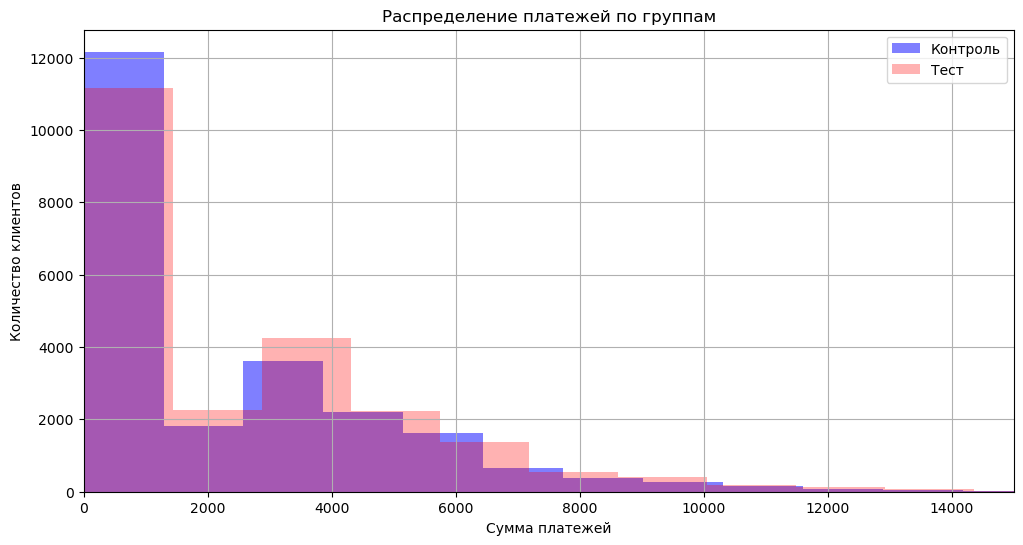

In [35]:
plt.figure(figsize=(12,6))
plt.hist(control_new, bins=30, alpha=0.5, label='Контроль', color='blue')
plt.hist(test_new, bins=30, alpha=0.3, label='Тест', color='red')

plt.xlim(0, 15000)

plt.xlabel('Сумма платежей')
plt.ylabel('Количество клиентов')
plt.title('Распределение платежей по группам')
plt.legend()
plt.grid(True)
plt.show()

In [37]:
print(f"Вывод:Из графика следует что в тестовой группе сумма платежей увеличилась.")

Вывод:Из графика следует что в тестовой группе сумма платежей увеличилась.


In [36]:
test_calc( control_new, test_new, alpha=0.05)

t-критерий: -9.4270
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)


In [39]:
mann_whitney_func( control_new, test_new, alpha=0.05)

Критерий Манна-Уитни: 249177209.5000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)


In [43]:
print(f"Вывод:Между контрольной и тестовой группами существует статистически значимая разница в средних значениях. Это означает, что наблюдаемые различия маловероятны возникшими случайно и, скорее всего, связаны с воздействием или фактором, который мы исследуем.Результат A/B-теста показывает, что изменение или условие, введённое в тестовой группе, действительно влияет на целевую метрику по сравнению с контрольной группой.")

Вывод:Между контрольной и тестовой группами существует статистически значимая разница в средних значениях. Это означает, что наблюдаемые различия маловероятны возникшими случайно и, скорее всего, связаны с воздействием или фактором, который мы исследуем.Результат A/B-теста показывает, что изменение или условие, введённое в тестовой группе, действительно влияет на целевую метрику по сравнению с контрольной группой.


In [44]:
control_conv = df_fin_filt[df_fin_filt['nflag_test'] == 0]['flag_pay']
test_conv = df_fin_filt[df_fin_filt['nflag_test'] == 1]['flag_pay']

In [45]:
test_calc( control_conv, test_conv, alpha=0.05)

t-критерий: -9.1619
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)


In [46]:
mann_whitney_func( control_conv, test_conv, alpha=0.05)

Критерий Манна-Уитни: 251432653.5000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)


In [47]:
print(f"Итоговый вывод:На основании проведенных тестов можно заключить, что существует статистически значимая разница в конверсии клиентов (оплатили или нет) между контрольной и тестовой группами. Это свидетельствует о том, что изменение или фактор, введённый для тестовой группы, влияет на вероятность оплаты.")

Итоговый вывод:На основании проведенных тестов можно заключить, что существует статистически значимая разница в конверсии клиентов (оплатили или нет) между контрольной и тестовой группами. Это свидетельствует о том, что изменение или фактор, введённый для тестовой группы, влияет на вероятность оплаты.


In [49]:
#Москва конверсия тест,контроль
control_conv_moscow = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == 'Москва')]['flag_pay']
test_conv_moscow = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == 'Москва')]['flag_pay']
#Москва платежи
control_pay_moscow = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == 'Москва')]['total_payments']
test_pay_moscow = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == 'Москва')]['total_payments']

test_calc(control_conv_moscow ,test_conv_moscow , alpha=0.05)
mann_whitney_func( control_conv_moscow,test_conv_moscow , alpha=0.05)

test_calc(control_pay_moscow ,test_pay_moscow , alpha=0.05)
mann_whitney_func( control_pay_moscow,test_pay_moscow , alpha=0.05)

t-критерий: -6.4278
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)
Критерий Манна-Уитни: 17987623.0000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)
t-критерий: -7.8916
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)
Критерий Манна-Уитни: 17534818.5000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)


In [50]:
print(f"Итог:В Москве эксперимент показал статистически значимое увеличение/уменьшение как конверсии, так и суммы платежей в тестовой группе.")

Итог:В Москве эксперимент показал статистически значимое увеличение/уменьшение как конверсии, так и суммы платежей в тестовой группе.


In [51]:
#Санкт-Петербург конверсия тест,контроль
control_conv_spb = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == 'Санкт-Петербург')]['flag_pay']
test_conv_spb = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == 'Санкт-Петербург')]['flag_pay']
#Санкт-Петербург платежи
control_pay_spb = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == 'Санкт-Петербург')]['total_payments']
test_pay_spb = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == 'Санкт-Петербург')]['total_payments']

test_calc(control_conv_spb ,test_conv_spb , alpha=0.05)
mann_whitney_func( control_conv_spb,test_conv_spb , alpha=0.05)

test_calc(control_pay_spb ,test_pay_spb , alpha=0.05)
mann_whitney_func( control_pay_spb,test_pay_spb , alpha=0.05)

t-критерий: -9.3525
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)
Критерий Манна-Уитни: 8881151.0000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)
t-критерий: -8.7606
p-value: 0.0000
Различия между средними статистически значимы (p < 0.05)
Критерий Манна-Уитни: 8809444.5000
p-value: 0.0000
Различия между распределениями статистически значимы (p < 0.05)


In [52]:
print(f" Вывод: В Санкт-Петербурге так же наблюдаеться статические различия между метриками тестовой и контрольной группы.")

 Вывод: В Санкт-Петербурге так же наблюдаеться статические различия между метриками тестовой и контрольной группы.


In [53]:
# Получаем список уникальных городов, исключая Москва и Санкт-Петербург
excluded_cities = ['Москва', 'Санкт-Петербург']
cities = [city for city in df_fin_filt['city'].unique() if city not in excluded_cities]

results = []

for city in cities:
    control_conv = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == city)]['flag_pay']
    test_conv = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == city)]['flag_pay']
    
    control_pay = df_fin_filt[(df_fin_filt['nflag_test'] == 0) & (df_fin_filt['city'] == city)]['total_payments']
    test_pay = df_fin_filt[(df_fin_filt['nflag_test'] == 1) & (df_fin_filt['city'] == city)]['total_payments']
    
    if len(control_conv) > 0 and len(test_conv) > 0:
        print(f"\nАнализ по городу: {city}")
        print("Конверсия:")
        test_calc(control_conv, test_conv, alpha=0.05)
        mann_whitney_func(control_conv, test_conv, alpha=0.05)
        
        print("Сумма платежей:")
        test_calc(control_pay, test_pay, alpha=0.05)
        mann_whitney_func(control_pay, test_pay, alpha=0.05)
    else:
        print(f"\nНедостаточно данных для анализа по городу: {city}")


Анализ по городу: Красноярск
Конверсия:
t-критерий: 0.2786
p-value: 0.7805
Нет статистически значимых различий между средними (p >= 0.05)
Критерий Манна-Уитни: 4419468.0000
p-value: 0.7805
Нет статистически значимых различий между распределениями (p >= 0.05)
Сумма платежей:
t-критерий: -0.1201
p-value: 0.9044
Нет статистически значимых различий между средними (p >= 0.05)
Критерий Манна-Уитни: 4413418.0000
p-value: 0.8770
Нет статистически значимых различий между распределениями (p >= 0.05)

Анализ по городу: Нижний Новгород
Конверсия:
t-критерий: 1.5331
p-value: 0.1263
Нет статистически значимых различий между средними (p >= 0.05)
Критерий Манна-Уитни: 11605.0000
p-value: 0.1264
Нет статистически значимых различий между распределениями (p >= 0.05)
Сумма платежей:
t-критерий: 1.1820
p-value: 0.2382
Нет статистически значимых различий между средними (p >= 0.05)
Критерий Манна-Уитни: 11575.0000
p-value: 0.1686
Нет статистически значимых различий между распределениями (p >= 0.05)

Анализ 

In [57]:
# Создаем список для хранения данных
results_list = []

# Получаем список уникальных городов
cities = df_fin_filt['city'].unique()

# Перебираем все города
for city in cities:
    # Получаем список торговых точек в городе
    trading_points = df_fin_filt[df_fin_filt['city'] == city]['id_trading_point'].unique()
    
    for tp in trading_points:
        # Фильтруем данные по торговой точке
        tp_data = df_fin_filt[df_fin_filt['id_trading_point'] == tp]
        
        # Разделяем на контроль и тест
        control_group = tp_data[tp_data['nflag_test'] == 0]
        test_group = tp_data[tp_data['nflag_test'] == 1]
        
        # Количество наблюдений
        count_control = len(control_group)
        count_test = len(test_group)
        count_all = len(tp_data)
        
        # Процент наблюдений данной ТТ от всех
        percent_count = (count_all / len(df_fin_filt)) * 100
        
        # Средние платежи
        avg_payment_control = control_group['total_payments'].mean() if count_control > 0 else np.nan
        avg_payment_test = test_group['total_payments'].mean() if count_test > 0 else np.nan
        
        # Стандартные отклонения
        sigma_control = control_group['total_payments'].std() if count_control > 1 else np.nan
        sigma_test = test_group['total_payments'].std() if count_test > 1 else np.nan
        
        # Разница средних
        diff = avg_payment_test - avg_payment_control
        
        # Статистический критерий t-test и p-value
        if count_control > 1 and count_test > 1:
            t_stat, p_value = ttest_ind(
                control_group['total_payments'],
                test_group['total_payments'],
                equal_var=False,
                nan_policy='omit'
            )
            ttest_value = t_stat
            pvalue_ttest = p_value
        else:
            ttest_value = np.nan
            pvalue_ttest = np.nan
        
        # Определяем лейбл по результатам теста:
        if pd.notnull(pvalue_ttest) and pvalue_ttest < 0.05:
            if diff > 0:
                label = 'positive'
            elif diff < 0:
                label = 'negative'
            else:
                label = 'neutral'
        else:
            label = 'neutral'
        
        # Добавляем строку в список как словарь
        results_list.append({
            'city': city,
            'id_trading_point': tp,
            'count_test': count_test,
            'count_control': count_control,
            'count_all': count_all,
            'percent_count': percent_count,
            'avg_payment_test': avg_payment_test,
            'avg_payment_control': avg_payment_control,
            'diff': diff,
            'sigma_test': sigma_test,
            'sigma_control': sigma_control,
            'ttest': ttest_value,
            'pvalue_ttest': pvalue_ttest,
            'label': label
        })

# После цикла создаем DataFrame из списка словарей
results_df = pd.DataFrame(results_list, columns=[
    'city', 'id_trading_point', 'count_test', 'count_control', 'count_all',
    'percent_count', 'avg_payment_test', 'avg_payment_control', 'diff',
    'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest', 'label'
])
results_df

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
0,Красноярск,212,593,575,1168,2.547937,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,0.483378,6.289187e-01,neutral
1,Красноярск,278,535,489,1024,2.233808,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,-1.830426,6.747772e-02,neutral
2,Красноярск,202,551,565,1116,2.434502,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,-1.153961,2.487664e-01,neutral
3,Красноярск,444,650,562,1212,2.643921,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,0.877051,3.806362e-01,neutral
4,Красноярск,277,708,709,1417,3.091119,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,0.981744,3.263942e-01,neutral
5,Нижний Новгород,13,142,150,292,0.636984,1970.549296,2336.186667,-365.637371,2575.944761,2709.895464,1.182026,2.381637e-01,neutral
6,Мурманск,54,633,640,1273,2.776990,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,-0.097569,9.222902e-01,neutral
7,Мурманск,55,422,425,847,1.847691,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,0.011268,9.910123e-01,neutral
8,Казань,991,270,294,564,1.230340,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,-2.230816,2.613223e-02,positive
9,Казань,699,482,494,976,2.129098,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,0.594576,5.522650e-01,neutral


In [59]:
# Создаем отдельные DataFrame для каждого исхода
df_positive = results_df[results_df['label'] == 'positive']
df_negative = results_df[results_df['label'] == 'negative']
df_neutral = results_df[results_df['label'] == 'neutral']

# Записываем в Excel с тремя листами
with pd.ExcelWriter('Диплом_финал.xlsx') as writer:
    df_positive.to_excel(writer, sheet_name='Положительные', index=False)
    df_negative.to_excel(writer, sheet_name='Отрицательные', index=False)
    df_neutral.to_excel(writer, sheet_name='Нейтральные', index=False)
